# Statistical Distribution Analysis

## Introduction

This notebook explores the distribution of continuous numerical variables across two different datasets:
1. **Heart Attack in Youth vs. Adult in Russia** (Sample size: 100)
2. **Red Wine Quality** (Sample size: 1000)

For each dataset, we will:
- Extract specific numerical features (e.g., Age, Blood Pressure, BMI, Acidity, Sugar, Alcohol).
- Visualize their probability density functions (PDF) using histograms.
- Fit appropriate theoretical probability distributions (Uniform, Normal, Gamma, Exponential) using `scipy.stats`.
- Perform Kolmogorov-Smirnov (K-S) tests to statistically evaluate the goodness-of-fit.

Finally, we will discuss how sample size impacts the sensitivity of the K-S test and interpret the results.

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import numpy as np

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## The first data set is "Heart Attack in youth vs Adult in Russia."

The sample size is 100.

Numeric variables:

- Age
- Blood_Pressure
- BMI: a value derived from weight and height of a person

[Link of data set](https://www.kaggle.com/datasets/ashaychoudhary/heart-attack-in-youth-vs-adult-in-russia)

In [ ]:
data1 = pd.read_csv("/content/drive/MyDrive/Datasets/heart_attack_russia_youth_vs_adult.csv")
data1 = data1[["Age", "Blood_Pressure", "BMI"]]
data1 = data1.sample(100)
data1.reset_index(drop=True, inplace=True)

In [ ]:
print(data1.info(), "\n")
print(data1.head(), "\n")

print(f"Age range: {data1['Age'].min()} - {data1['Age'].max()}")
print(f"Blood Pressure range: {data1['Blood_Pressure'].min()} - {data1['Blood_Pressure'].max()}")
print(f"BMI range: {data1['BMI'].min()} - {data1['BMI'].max()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             100 non-null    int64  
 1   Blood_Pressure  100 non-null    float64
 2   BMI             100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None 

   Age  Blood_Pressure   BMI
0   49            82.9  27.0
1   57           122.4  31.5
2   36           111.0  19.5
3   55           110.8  27.5
4   56           125.3  21.5 

Age range: 12 - 60
Blood Pressure range: 82.9 - 162.1
BMI range: 16.3 - 34.0


### 1. Analyse "Age"

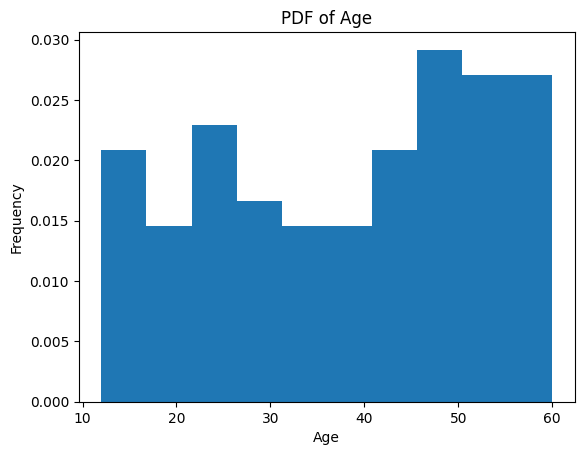

The mean of Age is:  38.23
The variance of Age is: 212.13848484848467 

It looks like a uniform distribution.


In [ ]:
# Plot Age
plt.hist(data1["Age"], bins = 10, density = True)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("PDF of Age")
plt.show()

print("The mean of Age is: ", data1["Age"].mean())
print("The variance of Age is:", data1["Age"].var(), "\n")

print("It looks like a uniform distribution.")

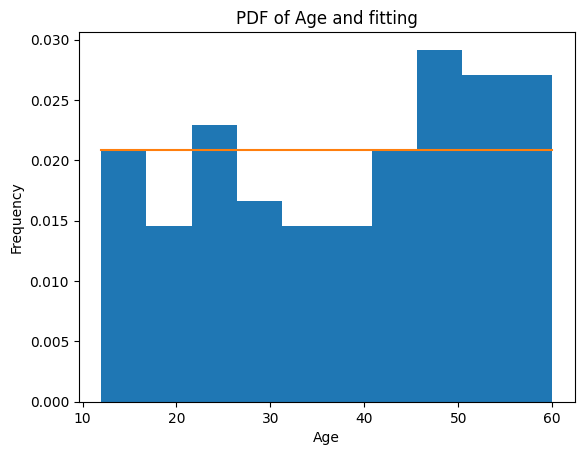

In [ ]:
# Fit Age
params = stats.uniform.fit(data1["Age"])

x = np.linspace(data1["Age"].min(), data1["Age"].max(), 100)
y = stats.uniform.pdf(x, loc = params[0], scale = params[1])

plt.hist(data1["Age"], bins = 10, density = True)
plt.plot(x, y)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("PDF of Age and fitting")
plt.show()

In [ ]:
# Perform the K-S test
_, pValue = stats.kstest(data1["Age"], 'uniform', args=(params[0], params[1]))

if pValue > 0.05:
    print("The data fits the uniform distribution (fail to reject H0).")
else:
    print("The data does not fit the uniform distribution (reject H0).")

The data fits the uniform distribution (fail to reject H0).


### 2. Analyse "Blood_Pressure"

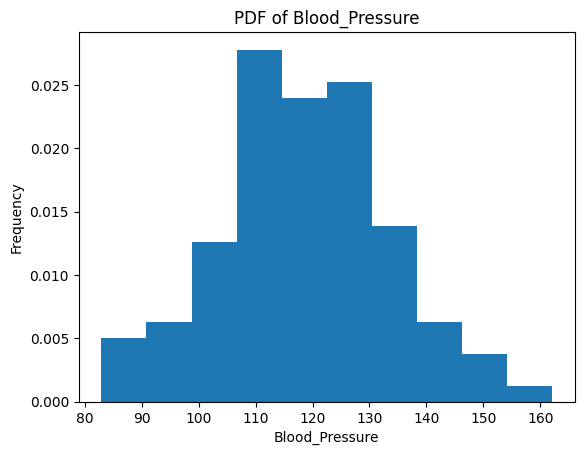

The mean of Blood_Pressure is:  118.73099999999998
The variance of Blood_Pressure is: 228.12397878787868 

It looks like a normal distribution.


In [ ]:
# Plot Blood_Pressure
plt.hist(data1["Blood_Pressure"], bins = 10, density = True)
plt.xlabel("Blood_Pressure")
plt.ylabel("Frequency")
plt.title("PDF of Blood_Pressure")
plt.show()

print("The mean of Blood_Pressure is: ", data1["Blood_Pressure"].mean())
print("The variance of Blood_Pressure is:", data1["Blood_Pressure"].var(), "\n")

print("It looks like a normal distribution.")

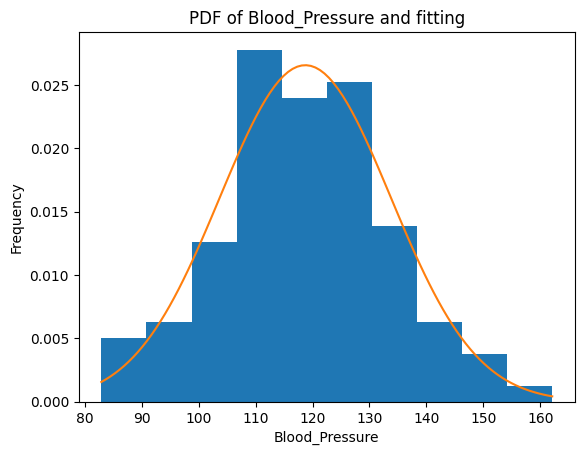

In [ ]:
# Fit Blood_Pressure
params = stats.norm.fit(data1["Blood_Pressure"])

x = np.linspace(data1["Blood_Pressure"].min(), data1["Blood_Pressure"].max(), 100)
y = stats.norm.pdf(x, params[0], params[1])

plt.hist(data1["Blood_Pressure"], bins = 10, density = True)
plt.plot(x, y)
plt.xlabel("Blood_Pressure")
plt.ylabel("Frequency")
plt.title("PDF of Blood_Pressure and fitting")
plt.show()

In [ ]:
# Perform the K-S test
_, pValue = stats.kstest(data1["Blood_Pressure"], 'norm', args=(params[0], params[1]))

if pValue > 0.05:
    print("The data fits the normal distribution (fail to reject H0).")
else:
    print("The data does not fit the normal distribution (reject H0).")

The data fits the normal distribution (fail to reject H0).


### 3. Analyse "BMI"

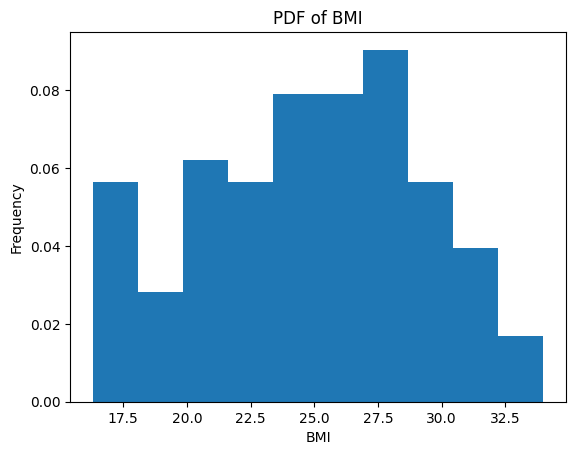

The mean of BMI is:  24.867000000000004
The variance of BMI is: 19.88324343434343 

It looks like a normal distribution.


In [ ]:
# Plot BMI
plt.hist(data1["BMI"], bins = 10, density = True)
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("PDF of BMI")
plt.show()

print("The mean of BMI is: ", data1["BMI"].mean())
print("The variance of BMI is:", data1["BMI"].var(), "\n")

print("It looks like a normal distribution.")

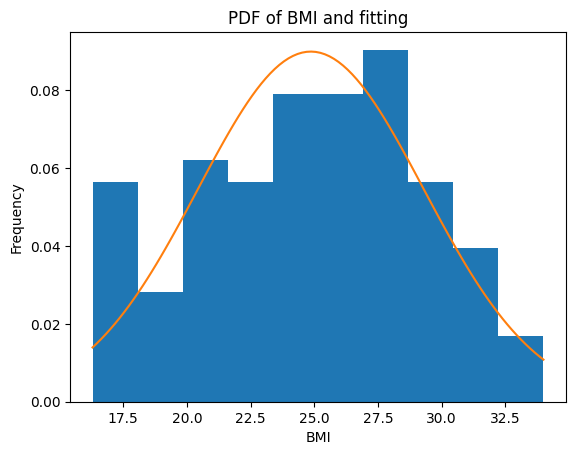

In [ ]:
# Fit BMI
params = stats.norm.fit(data1["BMI"])

x = np.linspace(data1["BMI"].min(), data1["BMI"].max(), 100)
y = stats.norm.pdf(x, params[0], params[1])

plt.hist(data1["BMI"], bins = 10, density = True)
plt.plot(x, y)
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("PDF of BMI and fitting")
plt.show()

In [ ]:
# Perform the K-S test
_, pValue = stats.kstest(data1["BMI"], 'norm', args=(params[0], params[1]))

if pValue > 0.05:
    print("The data fits the normal distribution (fail to reject H0).")
else:
    print("The data does not fit the normal distribution (reject H0).")

The data fits the normal distribution (fail to reject H0).


## The second data set is "Red Wine Quality".

The sample size is 1000.

Numeric variables:

- fixed acidity: an acid produced in the body from sources other than carbon dioxide, and is not excreted by the lungs

- residual sugar: is from natural grape sugars leftover in a wine after the alcoholic fermentation finishes

- alcohol

[Link of data set](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

In [ ]:
data2 = pd.read_csv("/content/drive/MyDrive/Datasets/winequality-red.csv")
data2 = data2[["fixed acidity", "residual sugar", "alcohol"]]
data2 = data2.sample(1000)
data2.reset_index(drop=True, inplace=True)

In [ ]:
print(data2.info(), "\n")
print(data2.head(), "\n")

print(f"fixed acidity range: {data2['fixed acidity'].min()} - {data2['fixed acidity'].max()}")
print(f"residual sugar range: {data2['residual sugar'].min()} - {data2['residual sugar'].max()}")
print(f"alcohol range: {data2['alcohol'].min()} - {data2['alcohol'].max()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fixed acidity   1000 non-null   float64
 1   residual sugar  1000 non-null   float64
 2   alcohol         1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB
None 

   fixed acidity  residual sugar  alcohol
0            7.3             2.0      9.9
1           12.4             2.6     10.4
2            9.0             2.8      9.2
3            7.0             1.8      9.2
4           10.5             2.2     12.0 

fixed acidity range: 4.7 - 15.9
residual sugar range: 0.9 - 15.4
alcohol range: 8.4 - 14.9


### 1. Analyse "fixed acidity"

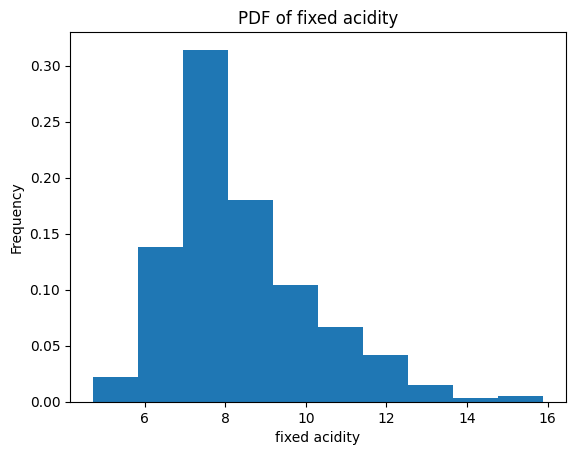

The mean of fixed acidity is:  8.375
The variance of fixed acidity is: 3.127122122122122 

It looks like a gamma distribution.


In [ ]:
# Plot fixed acidity
plt.hist(data2["fixed acidity"], bins = 10, density = True)
plt.xlabel("fixed acidity")
plt.ylabel("Frequency")
plt.title("PDF of fixed acidity")
plt.show()

print("The mean of fixed acidity is: ", data2["fixed acidity"].mean())
print("The variance of fixed acidity is:", data2["fixed acidity"].var(), "\n")

print("It looks like a gamma distribution.")

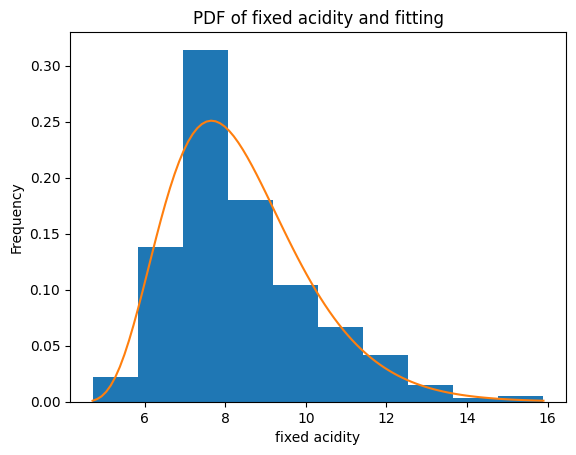

In [ ]:
# Fit fixed acidity
params = stats.gamma.fit(data2["fixed acidity"])

x = np.linspace(data2["fixed acidity"].min(), data2["fixed acidity"].max(), 100)
y = stats.gamma.pdf(x, params[0], params[1], params[2])

plt.hist(data2["fixed acidity"], bins = 10, density = True)
plt.plot(x, y)
plt.xlabel("fixed acidity")
plt.ylabel("Frequency")
plt.title("PDF of fixed acidity and fitting")
plt.show()

In [ ]:
# Perform the K-S test
_, pValue = stats.kstest(data2['fixed acidity'], 'gamma', args=(params[0], params[1], params[2]))

if pValue > 0.05:
    print("The data fits the gamma distribution (fail to reject H0).")
else:
    print("The data does not fit the gamma distribution (reject H0).")

print("But it looks like it fits gamma distribution well.")

The data does not fit the gamma distribution (reject H0).
But it looks like it fits gamma distribution well.


### 2. Analyse "residual sugar"

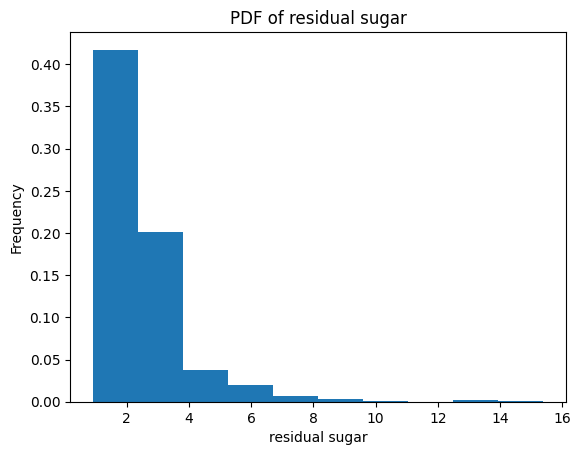

The mean of residual sugar is:  2.5661499999999995
The variance of residual sugar is: 1.9162979754754663 

It looks like a exponential distribution.


In [ ]:
# Plot residual sugar
plt.hist(data2["residual sugar"], bins = 10, density = True)
plt.xlabel("residual sugar")
plt.ylabel("Frequency")
plt.title("PDF of residual sugar")
plt.show()

print("The mean of residual sugar is: ", data2["residual sugar"].mean())
print("The variance of residual sugar is:", data2["residual sugar"].var(), "\n")

print("It looks like a exponential distribution.")

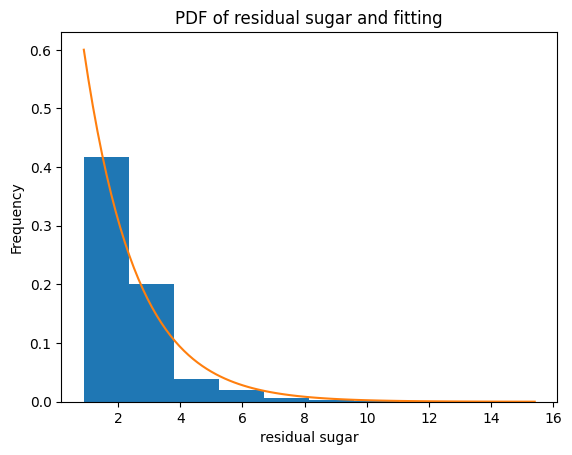

In [ ]:
# Fit residual sugar
params = stats.expon.fit(data2["residual sugar"])

x = np.linspace(data2["residual sugar"].min(), data2["residual sugar"].max(), 100)
y = stats.expon.pdf(x, params[0], params[1])

plt.hist(data2["residual sugar"], bins = 10, density = True)
plt.plot(x, y)
plt.xlabel("residual sugar")
plt.ylabel("Frequency")
plt.title("PDF of residual sugar and fitting")
plt.show()

In [ ]:
# Perform the K-S test
_, pValue = stats.kstest(data2['residual sugar'], 'expon', args=(params[0], params[1]))

if pValue > 0.05:
    print("The data fits the exponential distribution (fail to reject H0).")
else:
    print("The data does not fit the exponential distribution (reject H0).")

print("But it looks like it fits exponential distribution well.")

The data does not fit the exponential distribution (reject H0).
But it looks like it fits exponential distribution well.


### 3. Analyse "alcohol"

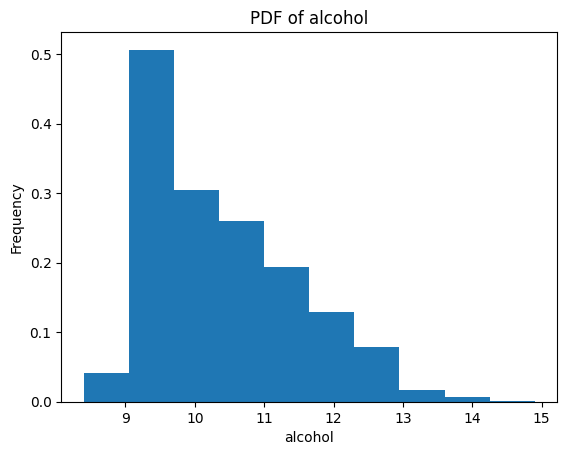

The mean of alcohol is:  10.396533333333332
The variance of alcohol is: 1.1177596307418545 

It looks like a gamma distribution.


In [ ]:
# Plot alcohol
plt.hist(data2["alcohol"], bins = 10, density = True)
plt.xlabel("alcohol")
plt.ylabel("Frequency")
plt.title("PDF of alcohol")
plt.show()

print("The mean of alcohol is: ", data2["alcohol"].mean())
print("The variance of alcohol is:", data2["alcohol"].var(), "\n")

print("It looks like a gamma distribution.")

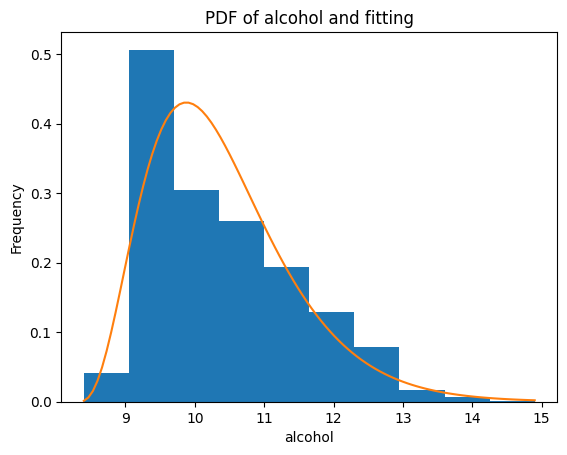

In [ ]:
# Fit alcohol
params = stats.gamma.fit(data2["alcohol"])

x = np.linspace(data2["alcohol"].min(), data2["alcohol"].max(), 100)
y = stats.gamma.pdf(x, params[0], params[1], params[2])

plt.hist(data2["alcohol"], bins = 10, density = True)
plt.plot(x, y)
plt.xlabel("alcohol")
plt.ylabel("Frequency")
plt.title("PDF of alcohol and fitting")
plt.show()

In [ ]:
# Perform the K-S test
_, pValue = stats.kstest(data2['alcohol'], 'gamma', args=(params[0], params[1], params[2]))

if pValue > 0.05:
    print("The data fits the gamma distribution (fail to reject H0).")
else:
    print("The data does not fit the gamma distribution (reject H0).")

print("But it looks like it fits gamma distribution well.")

The data does not fit the gamma distribution (reject H0).
But it looks like it fits gamma distribution well.


## Conclusion

In theory, a dataset with a larger sample size is expected to yield a higher quality fit. However, when evaluating the results using the p-value from the K-S test, the larger dataset surprisingly showed worse results (rejecting the null hypothesis).

This is a common phenomenon in statistical testing: as the sample size increases, tests like the Kolmogorov-Smirnov test become extremely sensitive to even minor, practically insignificant deviations from the theoretical distribution. Therefore, while the visual fit might look excellent, the large number of data points provides enough statistical power to detect slight imperfections, leading to a rejected hypothesis.